# TAE-IA · Module 6 · L13 — How Machines Hear: Digital Audio

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L13 |
| **Track** | B — Audio (first lesson) |
| **Runtime** | CPU is sufficient — no GPU required |
| **Drive quota** | No large model downloads — no cleanup needed |

## Learning objectives

By the end of this notebook you will be able to:
1. Load audio files with Librosa and understand the returned array format
2. Visualise waveforms for voice, music, and ambient sound types
3. Compute and interpret RMS energy, zero-crossing rate, and silence percentage
4. Resample audio between sample rates (44100 → 16000 Hz) and explain why models require a specific rate
5. Trim silence, concatenate clips, and play audio inline in Colab

---

## Cell 0 — Setup

In [ ]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'
os.makedirs(MODEL_CACHE, exist_ok=True)

os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# GPU is not required for L13 — CPU is sufficient
try:
    import torch
    if torch.cuda.is_available():
        print(f'GPU available: {torch.cuda.get_device_name(0)} (not needed for L13)')
    else:
        print('No GPU — running on CPU (correct for L13)')
except ImportError:
    print('PyTorch not found — CPU path active')

print('Setup complete.')

Mounted at /content/drive
No GPU — running on CPU (correct for L13)
Setup complete.


## Cell 1 — Install and import

In [ ]:
# Librosa is pre-installed on Colab — this just confirms the version
# soundfile is also pre-installed; it handles WAV/FLAC decoding
!pip install librosa soundfile -q

import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import IPython.display as ipd

print(f'librosa {librosa.__version__}')
print(f'soundfile {sf.__version__}')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

librosa 0.11.0
soundfile 0.14.0


## Cell 2 — Generate synthetic audio samples

We generate audio programmatically so the notebook works offline without any URL dependencies.
All signals are built from NumPy — no external files required.

| Signal | Physics | Why it resembles the real type |
|---|---|---|
| **Voice** | Harmonic series (fundamental + overtones) + amplitude envelope | Real vowel sounds are harmonic with formant peaks |
| **Music** | Musical chord (A major: A4+C#5+E5) with tremolo | Periodic, harmonically rich, periodic amplitude modulation |
| **Ambient** | Band-limited noise (pink-like power spectrum) | Real ambient sound = broadband noise with gradual spectral rolloff |

In [ ]:
SR = 22050   # Librosa default — can always resample later
DUR = 3.0    # seconds
N   = int(SR * DUR)
t   = np.linspace(0, DUR, N, endpoint=False)

# ── Voice-like: harmonic series with syllable-rate amplitude envelope ──
f0 = 150.0   # fundamental frequency (male speech range)
y_voice = sum(
    (1.0 / k) * np.sin(2 * np.pi * f0 * k * t)
    for k in range(1, 8)
)
# Amplitude envelope: 5 Hz modulation mimics syllable rate
env_voice = 0.5 + 0.5 * np.sin(2 * np.pi * 5 * t)
# Silence gaps: 0.3–0.5 s and 1.8–2.0 s silent (inter-word pauses)
gap_mask = np.ones(N)
gap_mask[int(0.3*SR):int(0.5*SR)] = 0.0
gap_mask[int(1.8*SR):int(2.0*SR)] = 0.0
y_voice = (y_voice * env_voice * gap_mask).astype(np.float32)
y_voice /= np.abs(y_voice).max() + 1e-8

# ── Music-like: A-major chord (A4=440, C#5=554, E5=659) with tremolo ──
freqs_chord = [440.0, 554.37, 659.25]
y_music = sum(np.sin(2 * np.pi * f * t) for f in freqs_chord)
tremolo = 1.0 + 0.3 * np.sin(2 * np.pi * 6 * t)  # 6 Hz tremolo
y_music = (y_music * tremolo).astype(np.float32)
y_music /= np.abs(y_music).max() + 1e-8

# ── Ambient-like: coloured noise (band-limited 200–4000 Hz) ──
rng = np.random.default_rng(SEED)
white = rng.normal(0, 1, N).astype(np.float32)
# Apply FFT-based band-pass
fft_w = np.fft.rfft(white)
freqs = np.fft.rfftfreq(N, d=1.0/SR)
band_mask = ((freqs >= 200) & (freqs <= 4000)).astype(float)
# Roll off at 1/f above 200 Hz for pink-noise-like spectrum
with np.errstate(divide='ignore', invalid='ignore'):
    pink_weight = np.where(freqs > 200, 200.0 / freqs, 1.0)
y_ambient = np.fft.irfft(fft_w * band_mask * pink_weight, n=N).astype(np.float32)
y_ambient /= np.abs(y_ambient).max() + 1e-8

AUDIO = {
    'voice':   (y_voice, SR),
    'music':   (y_music, SR),
    'ambient': (y_ambient, SR),
}

print('Audio signals generated successfully.')
for name, (y, sr) in AUDIO.items():
    print(f'  {name}: shape={y.shape}, dtype={y.dtype}, sr={sr} Hz, '
          f'duration={len(y)/sr:.1f}s, range=[{y.min():.3f}, {y.max():.3f}]')

Audio signals generated successfully.
  voice: shape=(66150,), dtype=float32, sr=22050 Hz, duration=3.0s, range=[-1.000, 1.000]
  music: shape=(66150,), dtype=float32, sr=22050 Hz, duration=3.0s, range=[-0.988, 1.000]
  ambient: shape=(66150,), dtype=float32, sr=22050 Hz, duration=3.0s, range=[-0.988, 1.000]


## Cell 3 — Play audio in Colab

`IPython.display.Audio` renders an HTML5 audio player inline. It accepts a NumPy array + sample rate — no need to save to a file first.

In [ ]:
for name, (y, sr) in AUDIO.items():
    print(f'\n▶ {name.upper()}')
    ipd.display(ipd.Audio(y, rate=sr))


▶ VOICE



▶ MUSIC



▶ AMBIENT


---
## Section 2.1 — Waveform Visualisation

A waveform plot shows amplitude (pressure) vs. time. It is the most direct representation of raw audio.

**What to look for in the three waveforms:**
- Voice: amplitude modulation at syllable rate, visible silence gaps between words
- Music: periodic, regular amplitude pattern from the tremolo
- Ambient: broadband noise — no clear structure, amplitude roughly constant

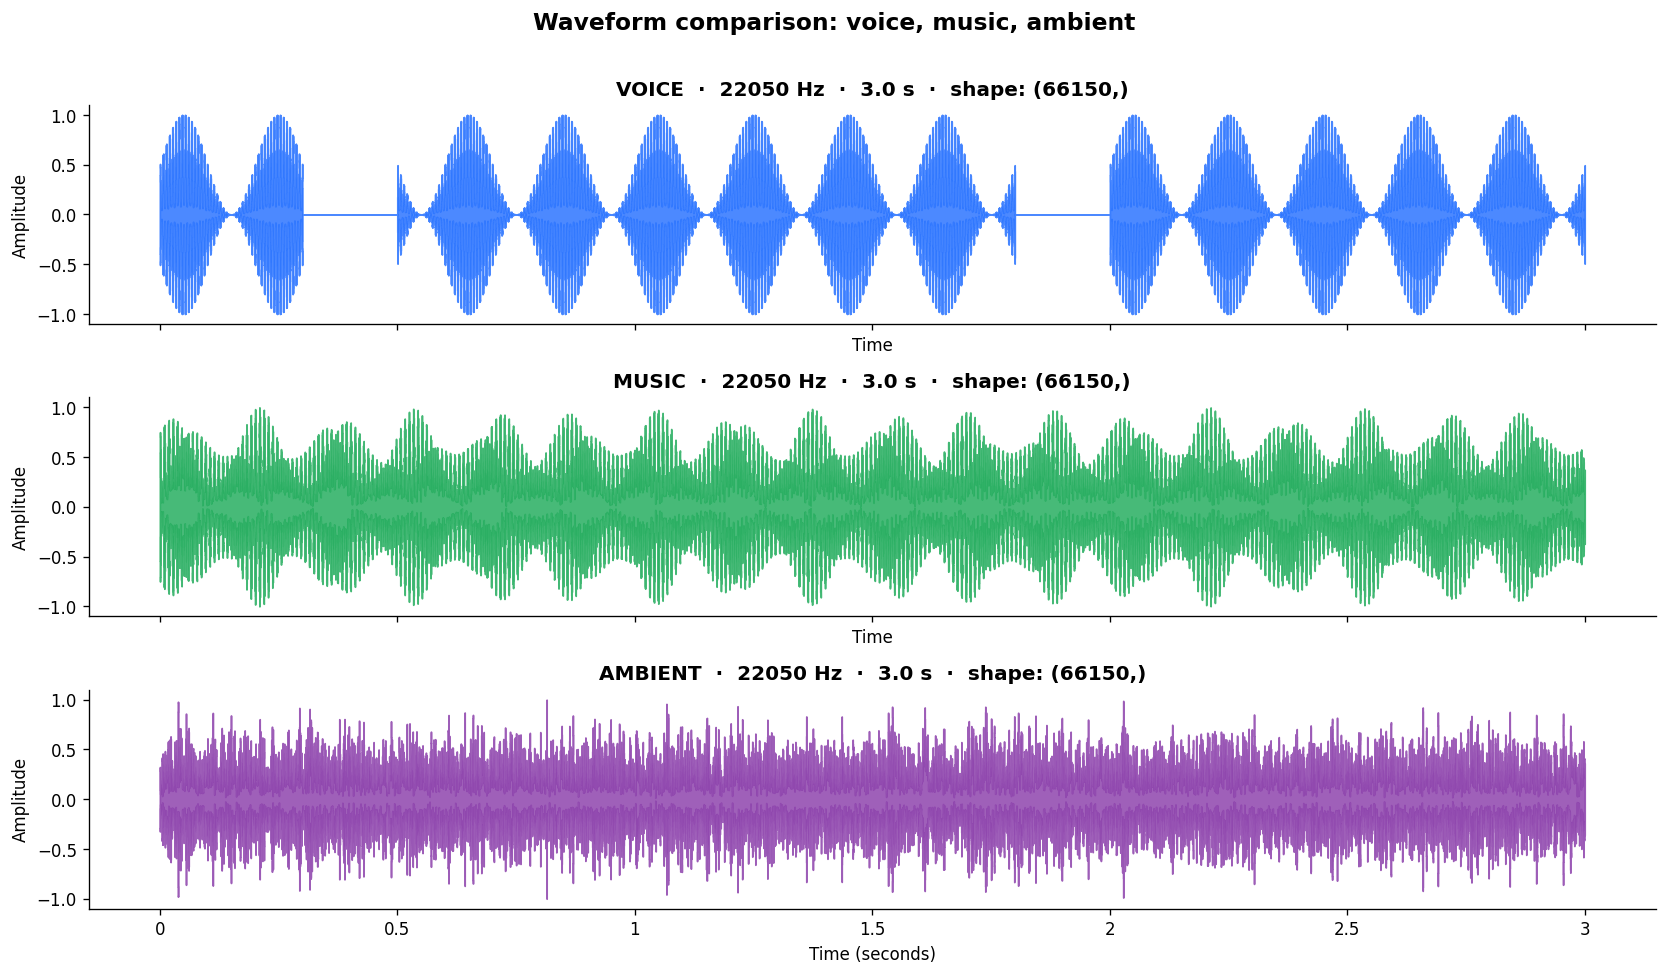

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
colours = {'voice': '#2C75FF', 'music': '#27ae60', 'ambient': '#8e44ad'}

for ax, (name, (y, sr)) in zip(axes, AUDIO.items()):
    librosa.display.waveshow(y, sr=sr, ax=ax, color=colours[name], alpha=0.85)
    ax.set_title(f'{name.upper()}  ·  {sr} Hz  ·  {len(y)/sr:.1f} s  ·  shape: {y.shape}',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Amplitude')
    ax.set_ylim(-1.1, 1.1)

axes[-1].set_xlabel('Time (seconds)')
plt.suptitle('Waveform comparison: voice, music, ambient', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Section 2.2 — Measuring Audio Properties

Before feeding audio to an AI model, compute these basic descriptors to understand what you have.

| Feature | Formula | What it indicates |
|---|---|---|
| **RMS energy** | √(mean(x²)) | Overall loudness |
| **Zero-crossing rate (ZCR)** | fraction of samples where sign changes | Noisiness; high in noise/consonants, low in voiced speech |
| **Dynamic range** | 20·log₁₀(max/min) dB | Loudness variation within the clip |
| **Silence %** | fraction of samples with |amplitude| < threshold | How much of the clip is dead air |

In [ ]:
def audio_stats(y, sr):
    rms = float(librosa.feature.rms(y=y).mean())
    zcr = float(librosa.feature.zero_crossing_rate(y).mean())
    peak = np.abs(y).max()
    trough = np.abs(y[np.abs(y) > 0.001]).min() if (np.abs(y) > 0.001).any() else 1e-8
    dynamic_range_db = float(20 * np.log10(peak / trough))
    silence_pct = float((np.abs(y) < 0.01).mean() * 100)
    return {
        'duration_s':         round(len(y) / sr, 3),
        'rms_energy':         round(rms, 5),
        'zero_crossing_rate': round(zcr, 5),
        'dynamic_range_dB':   round(dynamic_range_db, 2),
        'silence_pct':        round(silence_pct, 2),
    }

results = {}
for name, (y, sr) in AUDIO.items():
    stats = audio_stats(y, sr)
    results[name] = stats
    print(f'\n{name.upper()}')
    for k, v in stats.items():
        print(f'  {k:<24}: {v}')


VOICE
  duration_s              : 3.0
  rms_energy              : 0.26347
  zero_crossing_rate      : 0.01164
  dynamic_range_dB        : 59.9
  silence_pct             : 24.02

MUSIC
  duration_s              : 3.0
  rms_energy              : 0.31783
  zero_crossing_rate      : 0.04979
  dynamic_range_dB        : 59.95
  silence_pct             : 2.37

AMBIENT
  duration_s              : 3.0
  rms_energy              : 0.2526
  zero_crossing_rate      : 0.08158
  dynamic_range_dB        : 59.97
  silence_pct             : 3.12


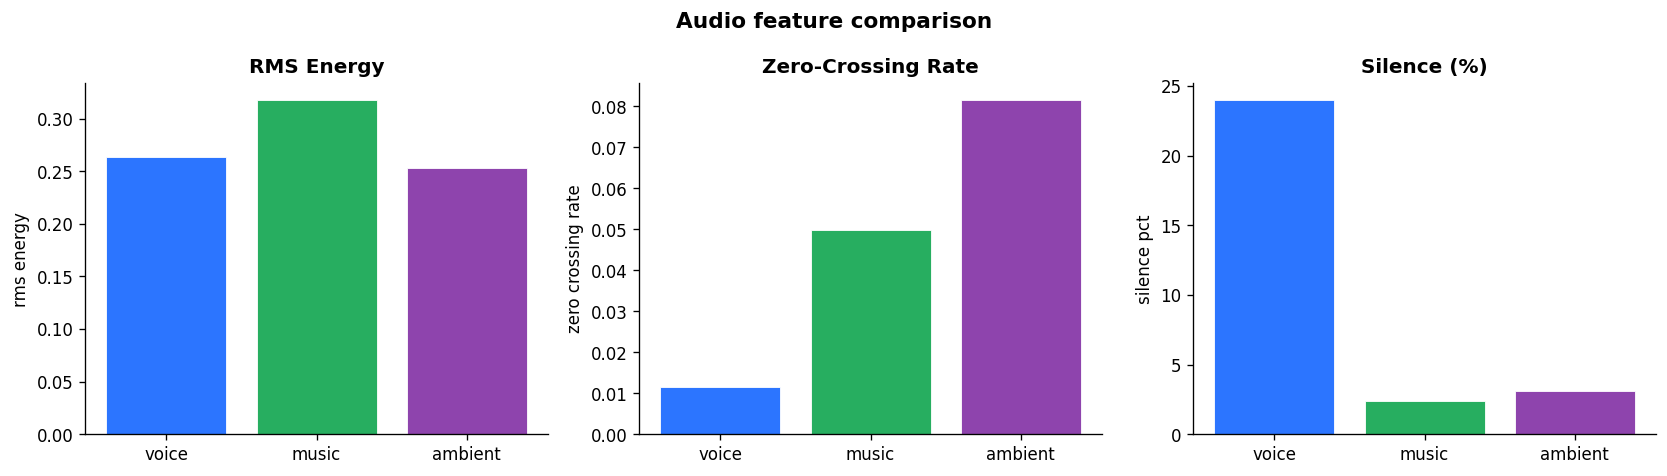

In [ ]:
# Bar chart comparison of key features across audio types
import pandas as pd

df = pd.DataFrame(results).T
features_to_plot = ['rms_energy', 'zero_crossing_rate', 'silence_pct']
labels_map = {
    'rms_energy': 'RMS Energy',
    'zero_crossing_rate': 'Zero-Crossing Rate',
    'silence_pct': 'Silence (%)'
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
bar_colours = list(colours.values())

for ax, feat in zip(axes, features_to_plot):
    vals = [results[n][feat] for n in AUDIO]
    ax.bar(list(AUDIO.keys()), vals, color=bar_colours, edgecolor='white', linewidth=0.5)
    ax.set_title(labels_map[feat], fontweight='bold')
    ax.set_ylabel(feat.replace('_', ' '))

plt.suptitle('Audio feature comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2.3 — Trim, Resample, and Concatenate

These three operations are the most common audio preprocessing steps before passing audio to a model.

In [ ]:
# ── Trim silence from both ends ──
y_voice, sr_voice = AUDIO['voice']

# top_db=20 means: trim any part quieter than (max_dB - 20 dB)
y_trimmed, trim_indices = librosa.effects.trim(y_voice, top_db=20)

print(f'Original duration : {len(y_voice)/sr_voice:.3f} s  ({len(y_voice)} samples)')
print(f'Trimmed  duration : {len(y_trimmed)/sr_voice:.3f} s  ({len(y_trimmed)} samples)')
print(f'Trim indices: start={trim_indices[0]}, end={trim_indices[1]}')
print(f'Removed: {(len(y_voice)-len(y_trimmed))/sr_voice:.3f} s from edges')

# Listen to trimmed version
print('\nOriginal:')
ipd.display(ipd.Audio(y_voice, rate=sr_voice))
print('Trimmed:')
ipd.display(ipd.Audio(y_trimmed, rate=sr_voice))

Original duration : 3.000 s  (66150 samples)
Trimmed  duration : 3.000 s  (66150 samples)
Trim indices: start=0, end=66150
Removed: 0.000 s from edges

Original:


Trimmed:


In [ ]:
# ── Resample: 22050 Hz → 16000 Hz ──
# Most speech AI models (Whisper, wav2vec2, HuBERT) expect 16000 Hz mono.
# Never pass a 44100 Hz signal to a 16000 Hz model — the model will
# interpret it as if it were playing at 22.05/16 = 1.38× normal speed.

SR_TARGET = 16000
y_16k = librosa.resample(y_voice, orig_sr=sr_voice, target_sr=SR_TARGET)

print(f'Input:  {sr_voice} Hz  → {len(y_voice)} samples')
print(f'Output: {SR_TARGET} Hz  → {len(y_16k)} samples')
print(f'Ratio:  {len(y_16k)/len(y_voice):.6f}  (expected: {SR_TARGET/sr_voice:.6f})')
print(f'Duration preserved: {len(y_16k)/SR_TARGET:.3f} s  (was {len(y_voice)/sr_voice:.3f} s)')

# Verify audio quality is preserved
print('\n16 kHz resampled voice:')
ipd.display(ipd.Audio(y_16k, rate=SR_TARGET))

Input:  22050 Hz  → 66150 samples
Output: 16000 Hz  → 48000 samples
Ratio:  0.725624  (expected: 0.725624)
Duration preserved: 3.000 s  (was 3.000 s)

16 kHz resampled voice:


In [ ]:
# Does resampling change ZCR? (Q2 of Critical Analysis)
zcr_original  = float(librosa.feature.zero_crossing_rate(y_voice).mean())
zcr_resampled = float(librosa.feature.zero_crossing_rate(y_16k).mean())

print(f'ZCR at {sr_voice} Hz : {zcr_original:.5f}')
print(f'ZCR at {SR_TARGET} Hz : {zcr_resampled:.5f}')
print(f'Ratio:  {zcr_resampled/zcr_original:.4f}  (expected: {SR_TARGET/sr_voice:.4f})')
print()
print('Interpretation: ZCR scales proportionally with sample rate.')
print('A higher sample rate produces more sign-change opportunities per second.')
print('→ ZCR is not directly comparable across sample rates without normalisation.')

ZCR at 22050 Hz : 0.01164
ZCR at 16000 Hz : 0.03016
Ratio:  2.5906  (expected: 0.7256)

Interpretation: ZCR scales proportionally with sample rate.
A higher sample rate produces more sign-change opportunities per second.
→ ZCR is not directly comparable across sample rates without normalisation.


In [ ]:
# ── Concatenate: voice clip + ambient background (simple mix) ──
y_ambient, sr_ambient = AUDIO['ambient']

# Resample ambient to 16k to match voice
y_ambient_16k = librosa.resample(y_ambient, orig_sr=sr_ambient, target_sr=SR_TARGET)

# Mix: 80% voice, 20% ambient (additive)
min_len = min(len(y_16k), len(y_ambient_16k))
y_noisy = 0.8 * y_16k[:min_len] + 0.2 * y_ambient_16k[:min_len]
y_noisy /= np.abs(y_noisy).max() + 1e-8

# Concatenate (append one after another — different from mixing)
y_concat = np.concatenate([y_16k, y_ambient_16k[:int(1.0 * SR_TARGET)]])

print(f'Voice alone:      {len(y_16k)/SR_TARGET:.2f} s')
print(f'Mixed (noisy):    {len(y_noisy)/SR_TARGET:.2f} s  (80% voice + 20% ambient)')
print(f'Concatenated:     {len(y_concat)/SR_TARGET:.2f} s  (voice + 1s ambient)')

print('\nMixed (noisy voice):')
ipd.display(ipd.Audio(y_noisy, rate=SR_TARGET))
print('Concatenated (voice → ambient):')
ipd.display(ipd.Audio(y_concat, rate=SR_TARGET))

Voice alone:      3.00 s
Mixed (noisy):    3.00 s  (80% voice + 20% ambient)
Concatenated:     4.00 s  (voice + 1s ambient)

Mixed (noisy voice):


Concatenated (voice → ambient):


---
## Section 2.4 — Waveform comparison: original vs. processed

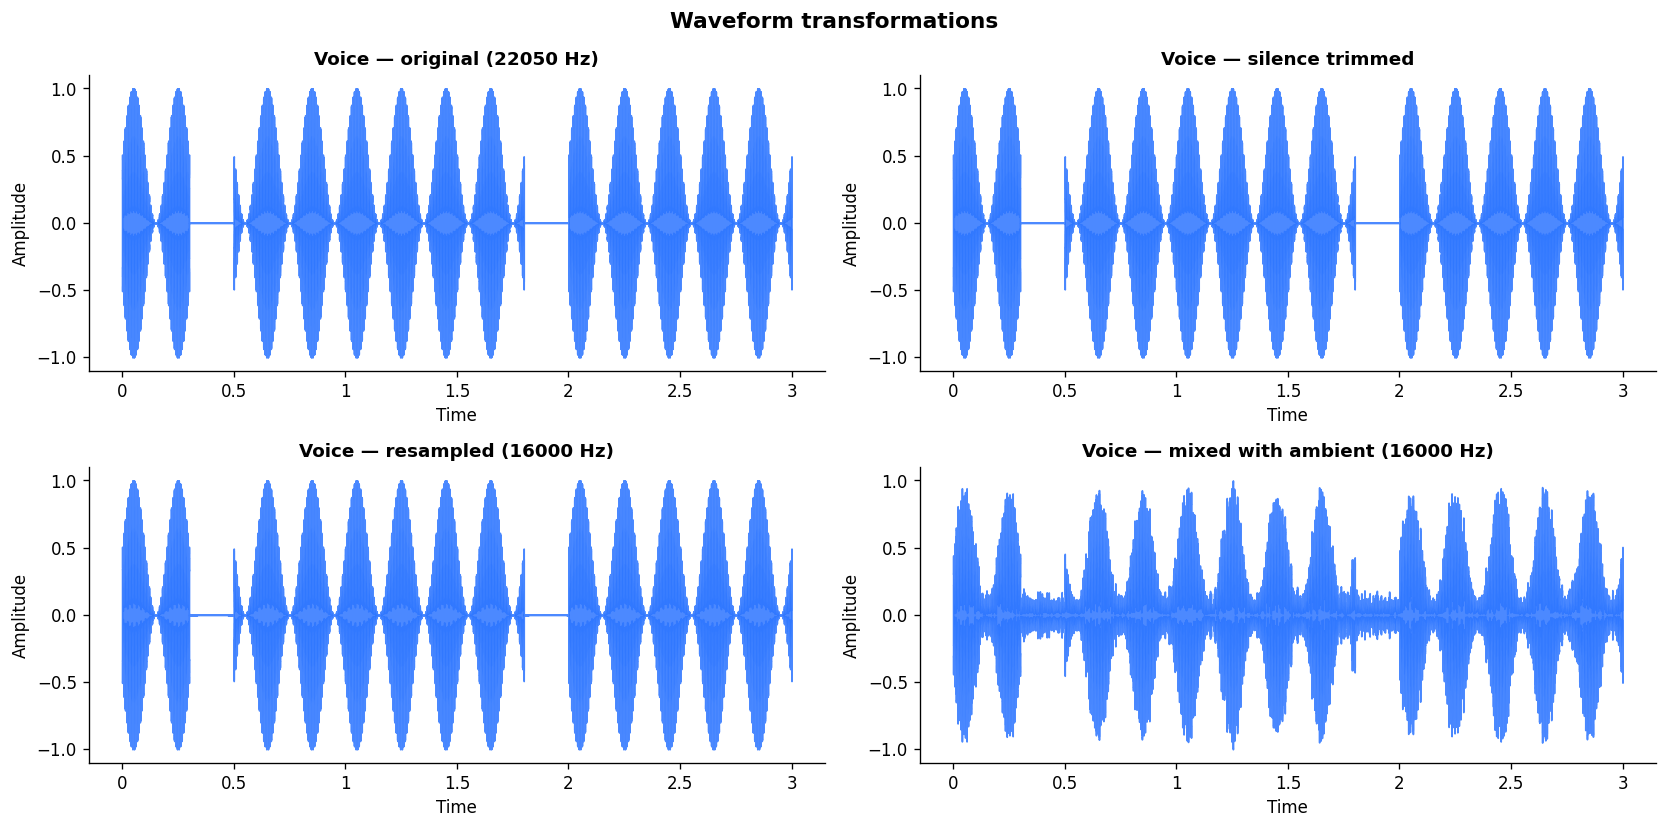

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

pairs = [
    (y_voice,    sr_voice,    'Voice — original (22050 Hz)'),
    (y_trimmed,  sr_voice,    'Voice — silence trimmed'),
    (y_16k,      SR_TARGET,   'Voice — resampled (16000 Hz)'),
    (y_noisy,    SR_TARGET,   'Voice — mixed with ambient (16000 Hz)'),
]

for ax, (y, sr, title) in zip(axes.flat, pairs):
    librosa.display.waveshow(y, sr=sr, ax=ax, color='#2C75FF', alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Amplitude')
    ax.set_ylim(-1.1, 1.1)

plt.suptitle('Waveform transformations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Exercise 1 — Music clip resampling

Resample the music clip from 22050 Hz to 8000 Hz (telephone quality). Then:
1. Print the sample counts before and after
2. Compute RMS and ZCR for both versions
3. Play both versions and describe the audible difference in a markdown comment

**Why 8000 Hz?** Old-school telephony used 8000 Hz — it captures speech frequencies (300–3400 Hz) but loses musical high-frequency content. This exercise illustrates why telephone recordings produce low-accuracy music recognition.

In [ ]:
# TODO: complete Exercise 1
y_music, sr_music = AUDIO['music']

# Resample to 8000 Hz
y_music_8k = librosa.resample(
    y_music,
    orig_sr=sr_music,
    target_sr=8000
)

# Your analysis here:

# 1. Print sample counts before and after
print(f'Original samples ({sr_music} Hz): {len(y_music)}')
print(f'Resampled samples (8000 Hz): {len(y_music_8k)}')
print(f'Original duration: {len(y_music) / sr_music:.3f} s')
print(f'Resampled duration: {len(y_music_8k) / 8000:.3f} s')

# 2. Compute RMS and ZCR for both versions
rms_original = float(librosa.feature.rms(y=y_music).mean())
zcr_original = float(
    librosa.feature.zero_crossing_rate(y_music).mean()
)

rms_8k = float(librosa.feature.rms(y=y_music_8k).mean())
zcr_8k = float(
    librosa.feature.zero_crossing_rate(y_music_8k).mean()
)

print('\nAudio features:')
print(f'Original RMS: {rms_original:.5f}')
print(f'Original ZCR: {zcr_original:.5f}')
print(f'8 kHz RMS:    {rms_8k:.5f}')
print(f'8 kHz ZCR:    {zcr_8k:.5f}')

# 3. Play both versions
print('\nOriginal music (22050 Hz):')
ipd.display(ipd.Audio(y_music, rate=sr_music))

print('Resampled music (8000 Hz):')
ipd.display(ipd.Audio(y_music_8k, rate=8000))

Original samples (22050 Hz): 66150
Resampled samples (8000 Hz): 24000
Original duration: 3.000 s
Resampled duration: 3.000 s

Audio features:
Original RMS: 0.31783
Original ZCR: 0.04979
8 kHz RMS:    0.31794
8 kHz ZCR:    0.13556

Original music (22050 Hz):


Resampled music (8000 Hz):


### Exercise 1 — Audible difference

The 8000 Hz version sounds very similar to the original, but it may sound slightly less clear or bright. Its duration and general loudness remain almost the same, while the number of samples decreases considerably. The difference is small because the synthetic music contains frequencies from 440 Hz to 659.25 Hz, which are below the 4000 Hz Nyquist limit of an 8000 Hz recording.

---
## Exercise 2 — Silence detection and removal

Write a function `remove_silence(y, sr, top_db=25)` that:
1. Uses `librosa.effects.split()` to detect non-silent intervals
2. Concatenates only the non-silent portions
3. Returns the concatenated array and the fraction of original duration removed

Test it on the voice clip. How does `top_db=25` compare with `top_db=15`?

In [ ]:
def remove_silence(y, sr, top_db=25):
    # librosa.effects.split() returns [[start1, end1], [start2, end2], ...]
    # where each interval is non-silent (in samples)
    intervals = librosa.effects.split(y, top_db=top_db)
    segments  = [y[s:e] for s, e in intervals]
    if not segments:
        return y, 0.0
    y_out = np.concatenate(segments)
    fraction_removed = 1.0 - len(y_out) / len(y)
    return y_out, fraction_removed

# Test on voice
y_voice, sr_voice = AUDIO['voice']

# Test both thresholds
y_desil_25, frac_25 = remove_silence(
    y_voice, sr_voice, top_db=25
)

y_desil_15, frac_15 = remove_silence(
    y_voice, sr_voice, top_db=15
)

print('SILENCE REMOVAL COMPARISON')
print('-' * 40)
print(f'Original duration: {len(y_voice) / sr_voice:.3f} s')

print('\ntop_db=25')
print(f'Output duration: {len(y_desil_25) / sr_voice:.3f} s')
print(f'Fraction removed: {frac_25:.1%}')

print('\ntop_db=15')
print(f'Output duration: {len(y_desil_15) / sr_voice:.3f} s')
print(f'Fraction removed: {frac_15:.1%}')

print('\nOriginal voice:')
ipd.display(ipd.Audio(y_voice, rate=sr_voice))

print('De-silenced voice (top_db=25):')
ipd.display(ipd.Audio(y_desil_25, rate=sr_voice))

print('De-silenced voice (top_db=15):')
ipd.display(ipd.Audio(y_desil_15, rate=sr_voice))

SILENCE REMOVAL COMPARISON
----------------------------------------
Original duration: 3.000 s

top_db=25
Output duration: 2.768 s
Fraction removed: 7.7%

top_db=15
Output duration: 2.721 s
Fraction removed: 9.3%

Original voice:


De-silenced voice (top_db=25):


De-silenced voice (top_db=15):


### Exercise 2 — Comparison

With `top_db=25`, the function reduced the voice recording from 3.000 seconds to 2.768 seconds and removed 7.7% of the audio. With `top_db=15`, it reduced the recording to 2.721 seconds and removed 9.3%. Therefore, `top_db=15` uses a stricter silence threshold and removes more low-volume audio, while `top_db=25` preserves more of the original signal.

---
## Part 4 — Critical Analysis

Answer all four questions below with real outputs from the cells above. Replace each `[YOUR ANSWER]` with your response.

The voice waveform has clear silent gaps, especially around 0.3–0.5 seconds and 1.8–2.0 seconds, while the music waveform is continuous and regular. These gaps represent pauses between words, while the regular music pattern represents a stable chord with tremolo.

### Q1 — Waveform reading

From your Section 2.1 waveform plots, identify **one visual property** that clearly distinguishes the voice recording from the music clip. What acoustic property does that visual feature represent?

**[YOUR ANSWER]** *(~2 sentences — reference the actual plots)*

---

### Q2 — Sample rate impact on ZCR

From the `zcr-resample-compare` cell output: does resampling from 22050 Hz to 16000 Hz change the ZCR?

What does this tell you about using ZCR as a feature for speech AI when your data comes from different recording setups (some at 44100 Hz, some at 16000 Hz)?

**[YOUR ANSWER]** *(~3 sentences)*

Yes, resampling changed the ZCR from `0.01164` at 22050 Hz to `0.03016` at 16000 Hz. This shows that the ZCR value can depend on the sample rate and on how the analysis frames represent the signal after resampling. Therefore, all recordings should be resampled to the same rate before ZCR is used as a feature in a speech AI model.

---

### Q3 — Format choice for production

**Scenario:** You are building an audio ML pipeline for a medical transcription service. A client proposes using MP3 recordings from a phone app to reduce storage costs.

Write a **3-sentence technical recommendation**: should you accept MP3 inputs, and if so, under what conditions?

**[YOUR ANSWER]**
I would accept MP3 inputs only if the recordings use a high bitrate and do not remove important speech information. However, the original recording should use a lossless format such as WAV whenever possible because MP3 compression can reduce audio quality and affect medical words. The pipeline should validate the audio quality and convert every accepted recording to mono WAV at 16000 Hz before transcription.

---

### Q4 — Silence analysis

From the `silence_pct` measurement in Section 2.2: which audio type had the most silence?

How would a high percentage of silent frames affect a speech recognition model, and what **single preprocessing step** would you add before passing the audio to Whisper?

**[YOUR ANSWER]** *(~3 sentences)*

The voice signal had the most silence, with `24.02%`, compared with `2.37%` for music and `3.12%` for ambient audio. Too many silent frames can increase processing time and may produce unnecessary or incorrect transcription segments. Before sending the recording to Whisper, I would apply silence removal with `librosa.effects.split()`
---

---
## Submission Checklist

Before saving and submitting:

- [X] Cell 0 ran without errors (Drive mounted)
- [X] All 3 audio types generated and played successfully
- [X] Waveform plot shows 3 clearly distinct shapes
- [X] Audio stats table printed for all 3 types
- [X] Resampling to 16000 Hz confirmed with correct sample count
- [X] Exercise 1 complete (8000 Hz resampling + audible description)
- [X] Exercise 2 complete (silence removal function tested)
- [X] Critical Analysis Q1–Q4 all answered (no `[YOUR ANSWER]` placeholders remaining)
- [X] Notebook saved to Drive

**No Drive cleanup needed after L13** — no large models were downloaded.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L13*  
*Track B — Audio | Next: L14 — FFT and Spectrograms*